# Complexity Analyzer — Dataset Evaluation

This notebook tests `complexity_analyzer.py` against a labeled CSV dataset.  
Each row contains a `code` snippet plus ground-truth `time_complexity` and `space_complexity` labels.

**Workflow**
1. Load the CSV  
2. Normalize labels → canonical O-notation strings  
3. Run the analyzer on every snippet  
4. Compare predictions vs. ground truth  
5. Report accuracy, confusion matrix, and failure cases  

## 0 · Setup

In [ ]:
import sys, importlib, warnings,os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(".."))

MODULE_PATH = Path('..\\Complexity\\complexity_analyzer.py') 
assert MODULE_PATH.exists(), f"Cannot find {MODULE_PATH}"

# Add folder to Python path
sys.path.insert(0, str(MODULE_PATH.parent))

# Import module
import Complexity.complexity_analyzer as ca

# Reload to pick up edits
importlib.reload(ca)

print('complexity_analyzer loaded ✓')

complexity_analyzer loaded ✓


## 1 · Load the Dataset

In [ ]:
CSV_PATH = '..\\Datasets\\python_data_clean.csv'

df = pd.read_csv(CSV_PATH)

COLUMN_ALIASES = {
    'Code':              'code',
    'Time Complexity':   'time_complexity',
    'Space Complexity':  'space_complexity',
}
df.rename(columns=COLUMN_ALIASES, inplace=True)

required = {'code', 'time_complexity', 'space_complexity'}
missing  = required - set(df.columns)
assert not missing, f"CSV is missing columns: {missing}"

df.dropna(subset=['code'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(df):,} rows")
display(df.head(3))

Loaded 1,373 rows


,code,space_complexity,time_complexity
0,# Python3 program for range minimum \r\n# quer...,linear,linear
1,# LCM of given range queries using Segment Tre...,constant,linear
2,# Python3 program to find LCA of u and v by\r\...,linear,linear


## 2 · Label Normalization

The dataset may use plain English (`linear`, `quadratic`) or O-notation (`O(n)`, `O(n^2)`).  
We map everything to the same strings the analyzer emits.

In [3]:
# ── Mapping: lowercase label → canonical O-notation ──────────────────────────
# Covers full English names, O()-notation variants, and the short-codes
# used in this dataset: constant, linear, logn, nlogn, quadratic, cubic, np
LABEL_MAP = {
    # O(1)
    'constant':        'O(1)',
    'o(1)':            'O(1)',
    # O(log n)
    'logarithmic':     'O(log n)',
    'logn':            'O(log n)',   # ← dataset short-code
    'log n':           'O(log n)',
    'o(log n)':        'O(log n)',
    'o(logn)':         'O(log n)',
    # O(n)
    'linear':          'O(n)',
    'o(n)':            'O(n)',
    # O(n log n)
    'linearithmic':    'O(n log n)',
    'nlogn':           'O(n log n)', # ← dataset short-code
    'n log n':         'O(n log n)',
    'o(n log n)':      'O(n log n)',
    'o(nlogn)':        'O(n log n)',
    'o(n*log n)':      'O(n log n)',
    # O(n²)
    'quadratic':       'O(n²)',
    'o(n^2)':          'O(n²)',
    'o(n2)':           'O(n²)',
    'o(n²)':           'O(n²)',
    # O(n^3)
    'cubic':           'O(n^3)',
    'o(n^3)':          'O(n^3)',
    'o(n3)':           'O(n^3)',
    # O(2ⁿ)
    'exponential':     'O(2ⁿ)',
    'np':              'O(2ⁿ)',      # ← dataset short-code (NP / exponential)
    'o(2^n)':          'O(2ⁿ)',
    'o(2ⁿ)':           'O(2ⁿ)',
    'o(n!)':           'O(n!)',
}

def normalize_label(raw):
    """Map a raw label string to canonical O-notation."""
    if pd.isna(raw):
        return 'UNKNOWN'
    key = str(raw).strip().lower()
    return LABEL_MAP.get(key, str(raw).strip())   # pass-through if already canonical

df['true_time']  = df['time_complexity'].map(normalize_label)
df['true_space'] = df['space_complexity'].map(normalize_label)

print("Unique time labels :", sorted(df['true_time'].unique()))
print("Unique space labels:", sorted(df['true_space'].unique()))

Unique time labels : ['O(1)', 'O(2ⁿ)', 'O(log n)', 'O(n log n)', 'O(n)', 'O(n^3)', 'O(n²)']
Unique space labels: ['O(1)', 'O(2ⁿ)', 'O(log n)', 'O(n log n)', 'O(n)', 'O(n²)']


## 3 · Run the Analyzer

In [4]:
def safe_analyze(code: str) -> dict:
    """Run the analyzer and return a flat result dict."""
    try:
        result = ca.analyze(code)
        return {
            'pred_time':  result.time_complexity,
            'pred_space': result.space_complexity,
            'time_reason':  result.time_reason,
            'space_reason': result.space_reason,
            'error': None,
        }
    except SyntaxError as e:
        return {'pred_time': 'SyntaxError', 'pred_space': 'SyntaxError',
                'time_reason': '', 'space_reason': '', 'error': str(e)}
    except Exception as e:
        return {'pred_time': 'Error', 'pred_space': 'Error',
                'time_reason': '', 'space_reason': '', 'error': str(e)}

results = df['code'].map(safe_analyze).apply(pd.Series)
df = pd.concat([df, results], axis=1)

errors = df[df['error'].notna()]
print(f"Rows with parse errors: {len(errors)}")
if len(errors):
    display(errors[['code', 'error']].head())

print(f"\nSuccessfully analyzed: {len(df) - len(errors):,} / {len(df):,} snippets")

Rows with parse errors: 67


,code,error
7,"//Given a binary matrix of M X N of integers, ...","invalid syntax (<unknown>, line 1)"
22,# Python 3 program to find maximum product\r\n...,"expected ':' (<unknown>, line 57)"
34,// A C++ program to implement Cartesian Tree s...,unterminated string literal (detected at line ...
42,'''Python program to find maximum value of Sum...,Missing parentheses in call to 'print'. Did yo...
60,# Python implementation of left rotation of\r\...,Missing parentheses in call to 'print'. Did yo...



Successfully analyzed: 1,306 / 1,373 snippets


## 4 · Accuracy Metrics

,Correct,Total,Accuracy
Metric,,,
Time Accuracy,660,1306,50.5%
Space Accuracy,896,1306,68.6%
Both Correct,482,1306,36.9%


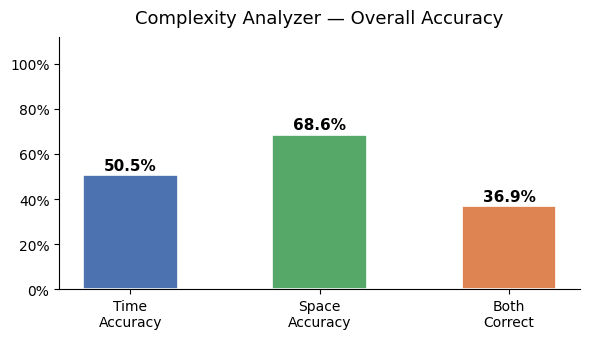

In [ ]:
ok = df[df['error'].isna()].copy()

ok['time_correct']  = ok['pred_time']  == ok['true_time']
ok['space_correct'] = ok['pred_space'] == ok['true_space']
ok['both_correct']  = ok['time_correct'] & ok['space_correct']

time_acc  = ok['time_correct'].mean()
space_acc = ok['space_correct'].mean()
both_acc  = ok['both_correct'].mean()

summary = pd.DataFrame({
    'Metric':   ['Time Accuracy', 'Space Accuracy', 'Both Correct'],
    'Correct':  [ok['time_correct'].sum(), ok['space_correct'].sum(), ok['both_correct'].sum()],
    'Total':    [len(ok)] * 3,
    'Accuracy': [time_acc, space_acc, both_acc],
})
summary['Accuracy'] = summary['Accuracy'].map('{:.1%}'.format)

display(summary.set_index('Metric'))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(
    ['Time\nAccuracy', 'Space\nAccuracy', 'Both\nCorrect'],
    [time_acc, space_acc, both_acc],
    color=['#4C72B0', '#55A868', '#DD8452'],
    edgecolor='white', linewidth=1.2, width=0.5
)
for bar, val in zip(bars, [time_acc, space_acc, both_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Complexity Analyzer — Overall Accuracy', fontsize=13, pad=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
# plt.savefig('accuracy_bar.png', dpi=150)
plt.show()
# 50.5%
# 68.6%
# 36.9%

## 5 · Per-Class Accuracy

── Time Complexity ──


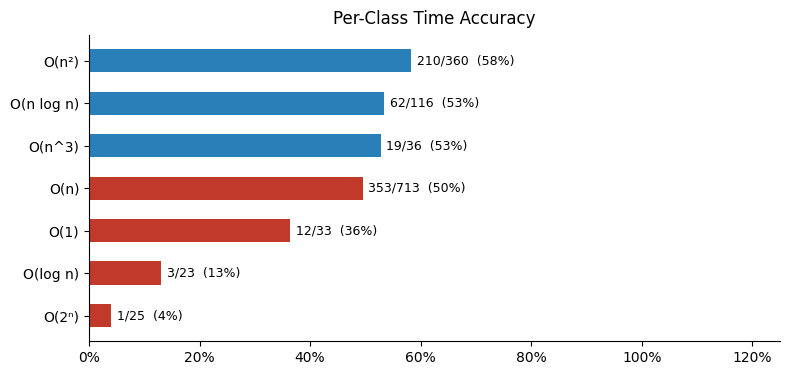


── Space Complexity ──


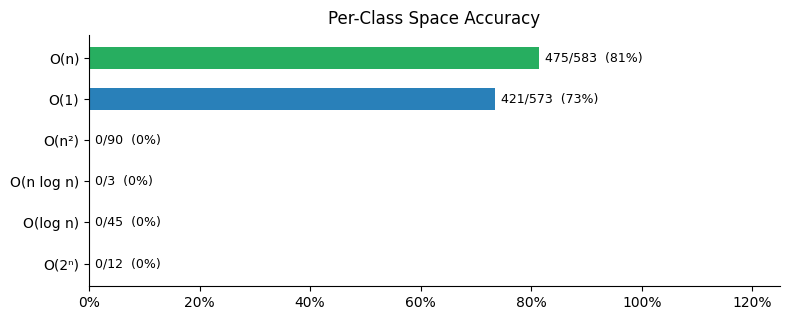

In [ ]:
def per_class_accuracy(df, true_col, pred_col, title):
    grouped = df.groupby(true_col).apply(
        lambda g: pd.Series({
            'count':    len(g),
            'correct':  (g[pred_col] == g[true_col]).sum(),
        })
    ).reset_index()
    grouped['accuracy'] = grouped['correct'] / grouped['count']
    grouped = grouped.sort_values('accuracy', ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(3, len(grouped) * 0.55)))
    colors = ['#c0392b' if a < 0.5 else '#2980b9' if a < 0.8 else '#27ae60'
              for a in grouped['accuracy']]
    bars = ax.barh(grouped[true_col], grouped['accuracy'], color=colors, height=0.55)
    for bar, (_, row) in zip(bars, grouped.iterrows()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{row['correct']:.0f}/{row['count']:.0f}  ({row['accuracy']:.0%})",
                va='center', fontsize=9)
    ax.set_xlim(0, 1.25)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title, fontsize=12, pad=8)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    # plt.savefig(f"{title.lower().replace(' ','_')}.png", dpi=150)
    plt.show()
    return grouped

print("── Time Complexity ──")
time_pc = per_class_accuracy(ok, 'true_time', 'pred_time', 'Per-Class Time Accuracy')

print("\n── Space Complexity ──")
space_pc = per_class_accuracy(ok, 'true_space', 'pred_space', 'Per-Class Space Accuracy')

## 6 · Confusion Matrices

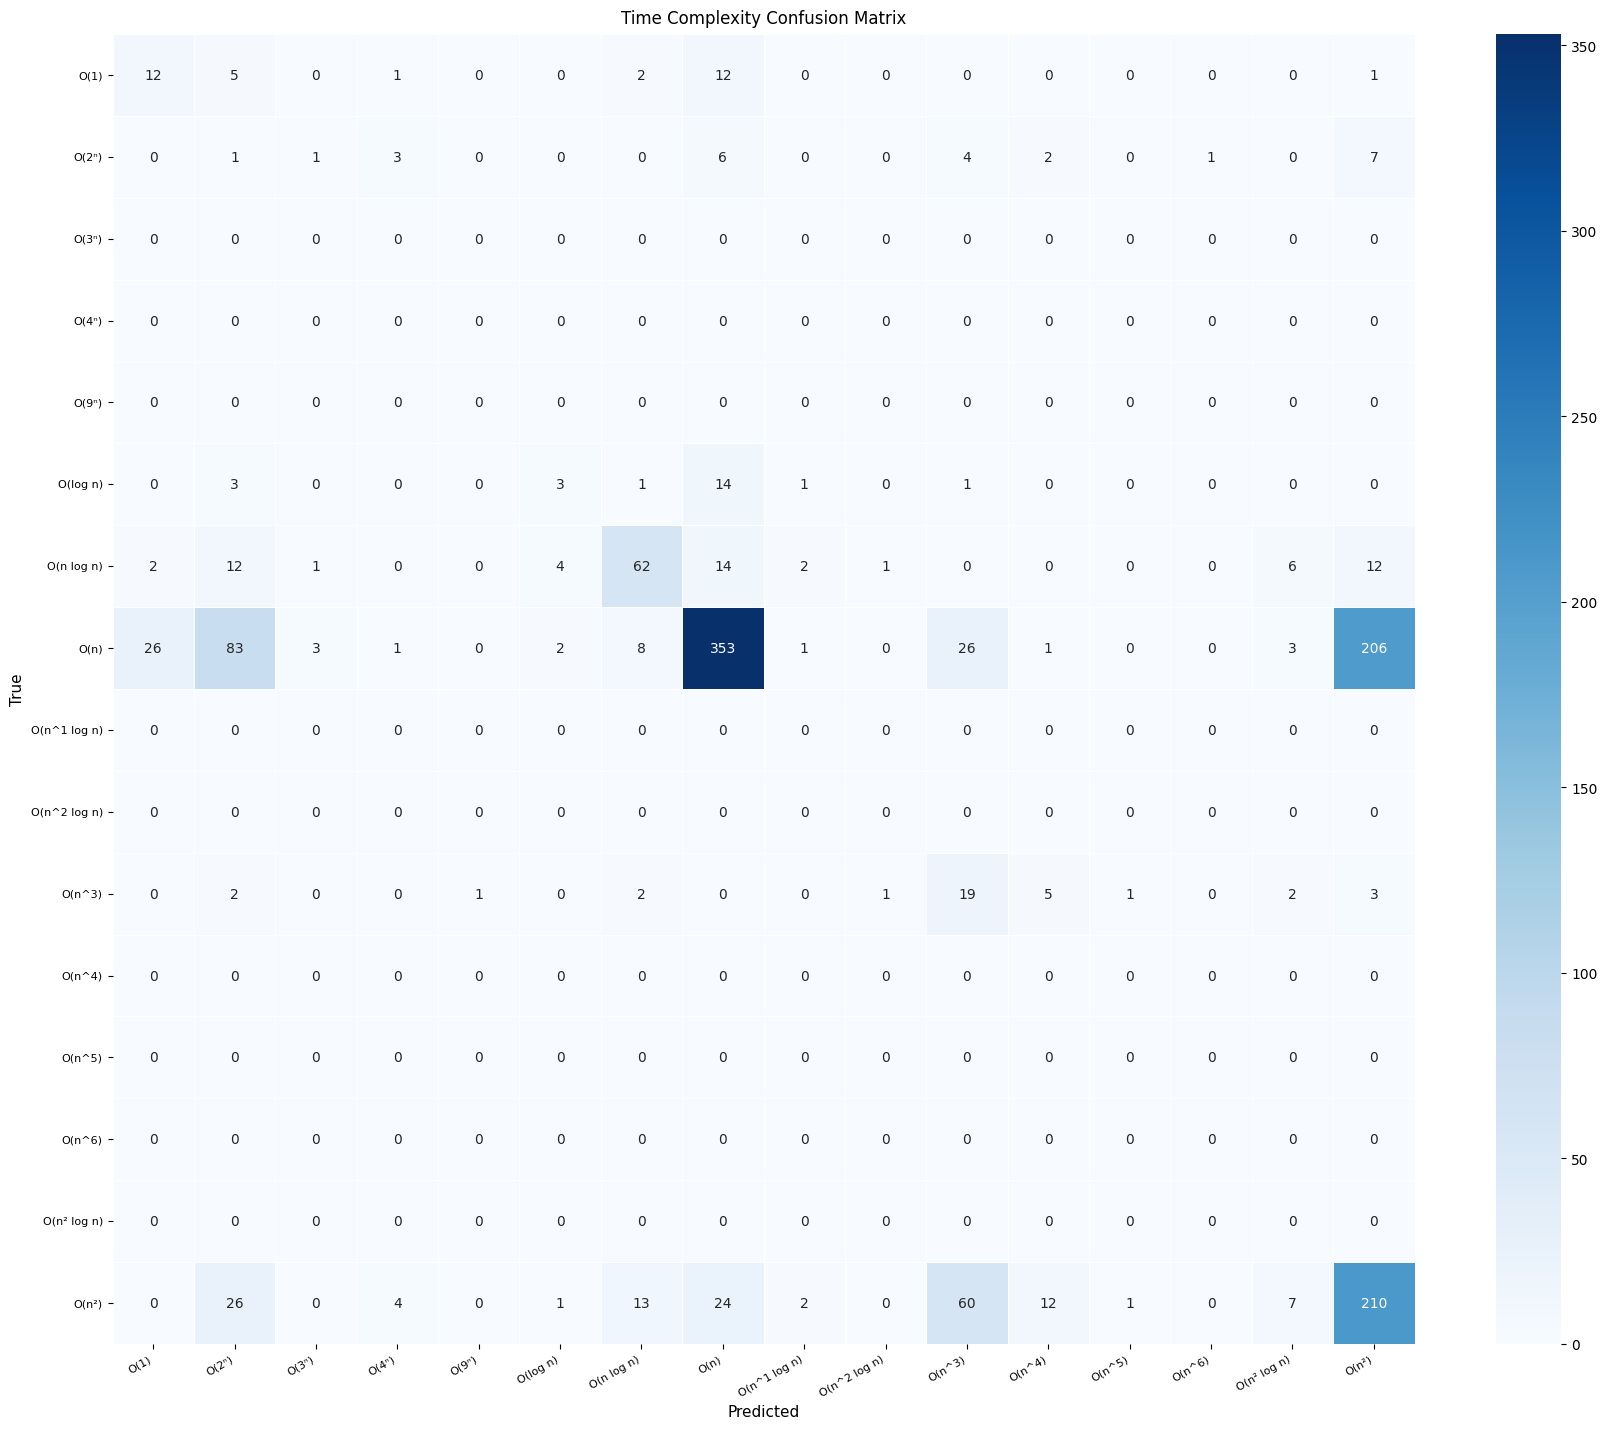

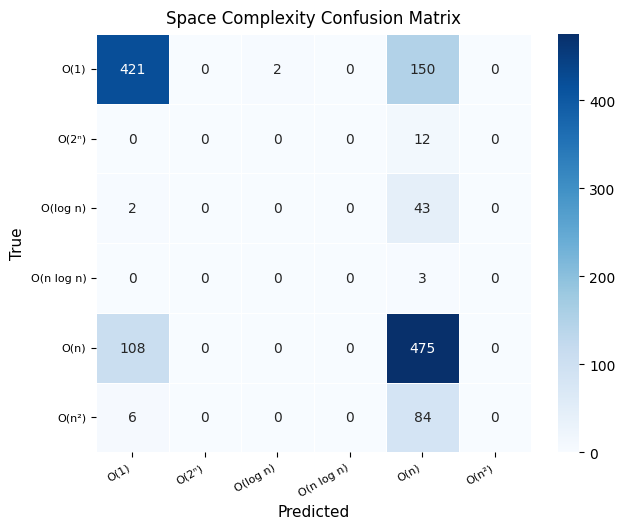

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion(df, true_col, pred_col, title):
    labels = sorted(set(df[true_col].unique()) | set(df[pred_col].unique()))
    cm = confusion_matrix(df[true_col], df[pred_col], labels=labels)
    fig, ax = plt.subplots(figsize=(max(5, len(labels)*1.1), max(4, len(labels)*0.9)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=12, pad=8)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    # plt.savefig(f"{title.lower().replace(' ','_')}.png", dpi=150)
    plt.show()

plot_confusion(ok, 'true_time',  'pred_time',  'Time Complexity Confusion Matrix')
plot_confusion(ok, 'true_space', 'pred_space', 'Space Complexity Confusion Matrix')

## 7 · Label Distribution

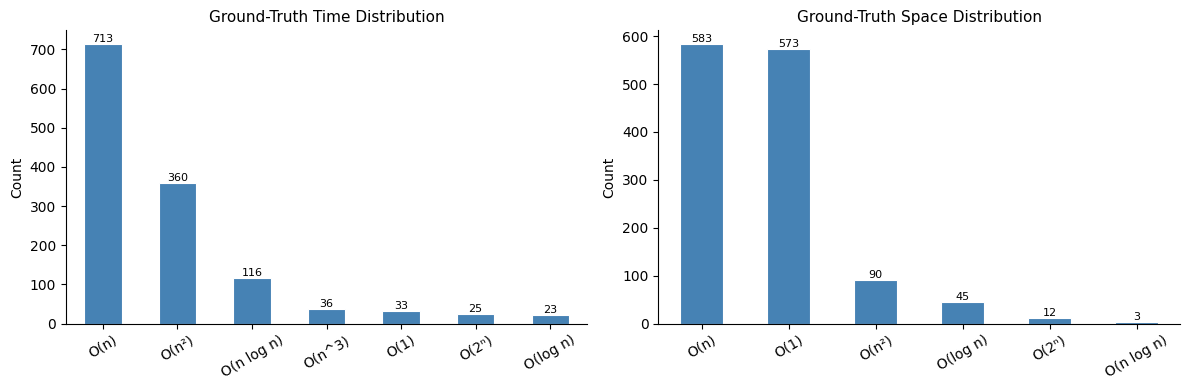

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'true_time',  'Ground-Truth Time Distribution'),
    (axes[1], 'true_space', 'Ground-Truth Space Distribution'),
]:
    counts = ok[col].value_counts()
    counts.plot.bar(ax=ax, color='steelblue', edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top','right']].set_visible(False)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig('label_distribution.png', dpi=150)
plt.show()

## 8 · Prediction Distribution vs Ground Truth

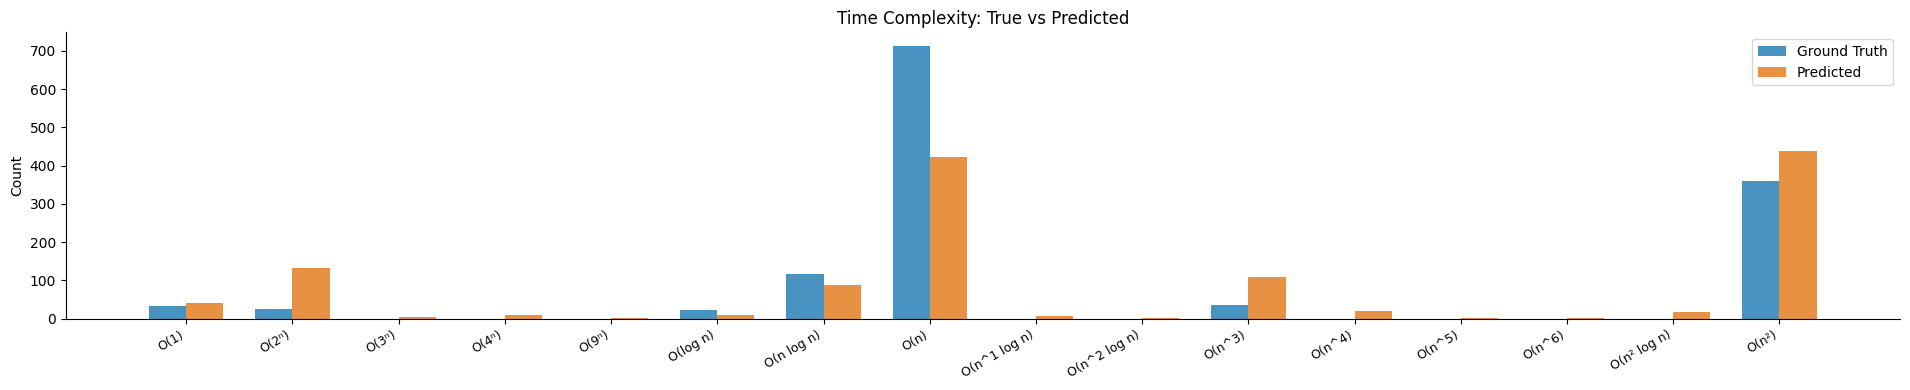

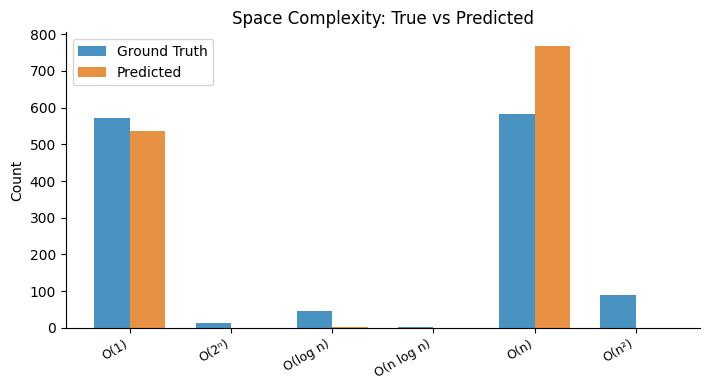

In [ ]:
def compare_distributions(df, true_col, pred_col, title):
    labels = sorted(set(df[true_col].unique()) | set(df[pred_col].unique()))
    true_counts = df[true_col].value_counts().reindex(labels, fill_value=0)
    pred_counts = df[pred_col].value_counts().reindex(labels, fill_value=0)

    x = np.arange(len(labels))
    w = 0.35
    fig, ax = plt.subplots(figsize=(max(6, len(labels)*1.2), 4))
    ax.bar(x - w/2, true_counts, width=w, label='Ground Truth', color='#2980b9', alpha=0.85)
    ax.bar(x + w/2, pred_counts, width=w, label='Predicted',    color='#e67e22', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    # plt.savefig(f"{title.lower().replace(' ','_')}.png", dpi=150)
    plt.show()

compare_distributions(ok, 'true_time',  'pred_time',  'Time Complexity: True vs Predicted')
compare_distributions(ok, 'true_space', 'pred_space', 'Space Complexity: True vs Predicted')

## 9 · Failure Analysis

In [10]:
failures = ok[~ok['both_correct']].copy()
print(f"Failures: {len(failures)} / {len(ok)} ({len(failures)/len(ok):.1%})\n")

print("Most common time mispredictions:")
time_errs = failures[~failures['time_correct']].groupby(['true_time','pred_time']).size()
display(time_errs.sort_values(ascending=False).head(10).rename('count').reset_index())

print("\nMost common space mispredictions:")
space_errs = failures[~failures['space_correct']].groupby(['true_space','pred_space']).size()
display(space_errs.sort_values(ascending=False).head(10).rename('count').reset_index())

Failures: 824 / 1306 (63.1%)

Most common time mispredictions:


,true_time,pred_time,count
0,O(n),O(n²),206
1,O(n),O(2ⁿ),83
2,O(n²),O(n^3),60
3,O(n),O(n^3),26
4,O(n²),O(2ⁿ),26
5,O(n),O(1),26
6,O(n²),O(n),24
7,O(n log n),O(n),14
8,O(log n),O(n),14
9,O(n²),O(n log n),13



Most common space mispredictions:


,true_space,pred_space,count
0,O(1),O(n),150
1,O(n),O(1),108
2,O(n²),O(n),84
3,O(log n),O(n),43
4,O(2ⁿ),O(n),12
5,O(n²),O(1),6
6,O(n log n),O(n),3
7,O(1),O(log n),2
8,O(log n),O(1),2


In [11]:
# ── Browse individual failure cases ──────────────────────────────────────────
FAILURE_SAMPLE = 5   # change to see more

for i, (_, row) in enumerate(failures.sample(min(FAILURE_SAMPLE, len(failures)),
                                              random_state=42).iterrows()):
    print(f"{'─'*60}")
    print(f"[{i+1}] Time:  true={row['true_time']:12}  pred={row['pred_time']}")
    print(f"     Space: true={row['true_space']:12}  pred={row['pred_space']}")
    print(f"     Time reason : {row['time_reason']}")
    print(f"     Space reason: {row['space_reason']}")
    snippet = str(row['code'])[:400].replace('\n', '\n     ')
    print(f"     Code snippet:\n     {snippet}")
    print()

────────────────────────────────────────────────────────────
[1] Time:  true=O(n)          pred=O(n²)
     Space: true=O(n)          pred=O(1)
     Time reason : Implicit O(n) operation (membership test, builtin scan, or comprehension) inside a loop → O(n²).
     Space reason: Only fixed-size variables used — constant extra space.
     Code snippet:
     # Python program to Count all
     # prefixes in given string with
     # greatest frequency
      
     # Function to print the prefixes
     def prefix(string1, alphabet1, alphabet2):
         count = 0
         non_empty_string = ""
          
         string2 = list(string1)
          
         # Loop for iterating the length of
         # the string and print the prefixes
         # and the count of query prefixes.
         for i in range(0, len(s

────────────────────────────────────────────────────────────
[2] Time:  true=O(n)          pred=O(n²)
     Space: true=O(1)          pred=O(1)
     Time reason : Two nested loops — quad

## 10 · Single Snippet Playground

Paste any code below to see what the analyzer returns.

In [13]:
SNIPPET = """
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1
"""

result = ca.analyze(SNIPPET)
print(result)

Time  : O(log n)  — Loop halves the search space on every iteration.
Space : O(1)  — Only fixed-size variables used — constant extra space.
